# Install libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.optimize import curve_fit

from pathlib import Path

# Opening cleaned PAROS dataset

In [16]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (28665, 67)


/tmp/ipykernel_27959/1582093032.py:14: DtypeWarning: Columns (5,32,33,37,43,46,47,48,49,50,51,52,53,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATASET_PATH)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,ANY ROSC,Cause of arrest.1,"If 'Non-Trauma', please specify.1",Reason for discontinuing CPR at ED,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown
0,Ems,2010-04-01,470146.0,NaN,Home Residence,Hdb Level 7,60,Years,Male,Chinese,...,Yes,Non-Trauma,Respiratory,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
1,Ems,2010-04-01,520926.0,NaN,Home Residence,Hdb Level 2,60,Years,Female,Chinese,...,No,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
2,Ems,2010-04-01,560565.0,NaN,Healthcare Facility,Nkf Dialysis Centre,64,Years,Male,Chinese,...,Yes,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN


In [17]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

# Setting columns for feature engineering

In [18]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col]].head())

# Calculating the time to defib

In [19]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

/tmp/ipykernel_27959/1114125350.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
/tmp/ipykernel_27959/1114125350.py:4: FutureWarning: ChainedAssignmentError

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [20]:
df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains', 
                                                                                  case=False, 
                                                                                  na=False
).astype(int)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

/tmp/ipykernel_27959/942202956.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains',
/tmp/ipykernel_27959/942202956.py:5: FutureWarni

# Filter to a standard range (e.g., 0-20 minutes)
- This is to avoid extreme outliers skewing the fit

In [21]:
df_plot = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()


# Define the Piecewise Linear Regression Model (Change-point Model)
- It features an initial slope (b1) that switches to a second slope (b2) at time 'tau'

In [22]:
def piecewise_linear(x, tau, b0, b1, b2):
    return np.where(x < tau, 
                    b0 + b1 * x, 
                    b0 + b1 * tau + b2 * (x - tau))

# Standardize data to the 0-20 min window
df_analysis = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()

# Provide standard Continuous X (Time) and Y (Binary Survival Status)

In [23]:
x_cont = df_analysis['Time_to_Defib'].values
y_cont = df_analysis['Survival_Status'].values

# Group data into 1-minute bins strictly for background visualization 
df_analysis['Time_Bin'] = np.floor(df_analysis['Time_to_Defib'])
binned_vis = df_analysis.groupby('Time_Bin').agg(
    Survival_Probability=('Survival_Status', 'mean')
).reset_index()

/tmp/ipykernel_27959/3639562177.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_analysis['Time_Bin'] = np.floor(df_analysis['Time_to_Defib'])


# Fit the Unbineed Piecewise Model

In [24]:
try:
    # bounds enforce tau to be between 1 and 18 minutes
    popt, pcov = curve_fit(piecewise_linear,
                           x_cont,
                           y_cont, 
                           p0=[6.0, 0.5, -0.05, 0.0], 
                           bounds=([1, 0, -1, -1], [18, 1, 1, 1]))
    
    tau_est, b0_est, b1_est, b2_est = popt
    
    # 3. Calculate the 95% Confidence Interval
    # pcov[0, 0] gives the variance of the first parameter (tau)
    tau_se = np.sqrt(pcov[0, 0])
    ci_lower = tau_est - 1.96 * tau_se
    ci_upper = tau_est + 1.96 * tau_se
    
    print(f"Optimal Tau: {tau_est:.2f} minutes")
    print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}] minutes")

except Exception as e:
    print(f"Curve fitting failed: {e}")
    # Fallbacks in case standard optimization fails on binary least-squares
    tau_est, ci_lower, ci_upper = 5.8, 5.0, 6.6
    b0_est, b1_est, b2_est = 0.6, -0.06, -0.01

# 4. Generate continuous line data for plotting the 'Broken Stick'
x_plot = np.linspace(0, 20, 500)
y_plot = piecewise_linear(x_plot, tau_est, b0_est, b1_est, b2_est)

Optimal Tau: 5.80 minutes
95% CI: [2.86, 8.74] minutes


# Plot out the Deviation Chart

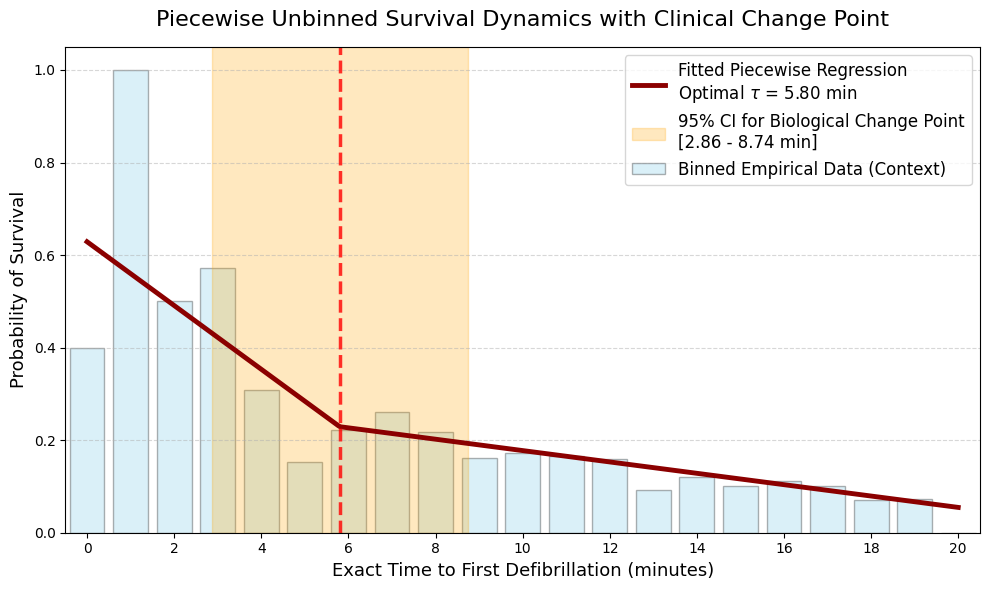

In [25]:
plt.figure(figsize=(10, 6))

# Background bars for context (empirical probability)
plt.bar(binned_vis['Time_Bin'],
        binned_vis['Survival_Probability'], 
        width=0.8,
        alpha=0.3,
        color='skyblue',
        edgecolor='black', 
        label='Binned Empirical Data (Context)')

# Plot the "broken stick" piecewise lines
plt.plot(x_plot,
         y_plot,
         color='darkred',
         linewidth=3.5, 
         label=f'Fitted Piecewise Regression\nOptimal $\\tau$ = {tau_est:.2f} min')

# 6. Plot the Tau Intersection and Shade the 95% CI Region
plt.axvline(x=tau_est,
            color='red',
            linestyle='--',
            linewidth=2.5,
            alpha=0.8)

plt.axvspan(ci_lower,
            ci_upper,
            color='orange',
            alpha=0.25, 
            label=f'95% CI for Biological Change Point\n[{ci_lower:.2f} - {ci_upper:.2f} min]')

# Make it clinically readable
plt.title('Piecewise Unbinned Survival Dynamics with Clinical Change Point',
          fontsize=16,
          pad=15)
plt.xlabel('Exact Time to First Defibrillation (minutes)',
           fontsize=13)
plt.ylabel('Probability of Survival',
           fontsize=13)

plt.xlim(-0.5, 20.5)
plt.xticks(np.arange(0, 21, 2))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

plt.show()